# Salary Benchmarking Analysis (Job Postings Dataset)

This project analyzes job postings to understand salary competitiveness, detect outliers, and recommend fair salaries based on market data.

In [1]:
import pandas as pd

df = pd.read_csv("/Users/maegalarajakumar/Downloads/duckdb_project/SGJobData.csv")
df.head()

,categories,employmentTypes,metadata_expiryDate,metadata_isPostedOnBehalf,metadata_jobPostId,metadata_newPostingDate,metadata_originalPostingDate,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,...,occupationId,positionLevels,postedCompany_name,salary_maximum,salary_minimum,salary_type,status_id,status_jobStatus,title,average_salary
0,"[{""id"":13,""category"":""Environment / Health""},{...",Permanent,2023-05-08,False,MCF-2023-0252866,2023-04-08,2023-03-30,2,5,151,...,NaN,Executive,WORKSTONE PTE. LTD.,2800,2000,Monthly,0,Closed,Food Technologist - Clementi | Entry Level | U...,2400.0
1,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273977,2023-04-08,2023-04-08,0,0,55,...,NaN,Executive,TRUST RECRUIT PTE. LTD.,5500,4000,Monthly,0,Closed,"Software Engineer (Fab Support) (Java, CIM, Up...",4750.0
2,"[{""id"":33,""category"":""Repair and Maintenance""}]",Full Time,2023-04-22,False,MCF-2023-0273994,2023-04-08,2023-04-08,0,7,99,...,NaN,Senior Executive,PU TIEN SERVICES PTE. LTD.,4600,3800,Monthly,0,Closed,Senior Technician,4200.0
3,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273991,2023-04-08,2023-04-08,0,6,113,...,NaN,Senior Executive,TRUST RECRUIT PTE. LTD.,10000,5000,Monthly,0,Closed,"Senior .NET Developer (.NET Core, MVC, MVVC, S...",7500.0
4,"[{""id"":2,""category"":""Admin / Secretarial""}]",Full Time,2023-05-08,False,MCF-2023-0273976,2023-04-08,2023-04-08,0,3,99,...,NaN,Non-executive,EATZ CATERING SERVICES PTE. LTD.,3400,2400,Monthly,0,Closed,Sales / Admin Cordinator,2900.0


## Business Questions

This analysis aims to answer:

1. Are we paying competitively in the market?
2. Are we overpaying or underpaying for certain roles?
3. What should we offer for a given role and experience level?

In [2]:
#Check missing values (overall)
df.isnull().sum()

categories                               3988
employmentTypes                          3988
metadata_expiryDate                      3988
metadata_isPostedOnBehalf                   0
metadata_jobPostId                       3988
metadata_newPostingDate                  3988
metadata_originalPostingDate             3988
metadata_repostCount                        0
metadata_totalNumberJobApplication          0
metadata_totalNumberOfView                  0
minimumYearsExperience                      0
numberOfVacancies                           0
occupationId                          1048585
positionLevels                           3988
postedCompany_name                       3988
salary_maximum                              0
salary_minimum                              0
salary_type                              3988
status_id                                   0
status_jobStatus                         3988
title                                    3988
average_salary                    

In [3]:
(df.isnull().sum() / len(df)) * 100

categories                              0.380322
employmentTypes                         0.380322
metadata_expiryDate                     0.380322
metadata_isPostedOnBehalf               0.000000
metadata_jobPostId                      0.380322
metadata_newPostingDate                 0.380322
metadata_originalPostingDate            0.380322
metadata_repostCount                    0.000000
metadata_totalNumberJobApplication      0.000000
metadata_totalNumberOfView              0.000000
minimumYearsExperience                  0.000000
numberOfVacancies                       0.000000
occupationId                          100.000000
positionLevels                          0.380322
postedCompany_name                      0.380322
salary_maximum                          0.000000
salary_minimum                          0.000000
salary_type                             0.380322
status_id                               0.000000
status_jobStatus                        0.380322
title               

In [4]:
df["average_salary"].isnull().sum()

0

## Missing Values (Salary)

The salary column contains no missing values.

Therefore, no removal or imputation was required for salary data.

In [5]:
#dentifying Outliers
lower = df["average_salary"].quantile(0.01)
upper = df["average_salary"].quantile(0.99)

lower, upper

(92.5, 16666.5)

In [6]:
#Handling Outliers (Clipping)
df_clean = df.copy()

df_clean["average_salary"] = df_clean["average_salary"].clip(lower, upper)

In [7]:
import matplotlib.pyplot as plt

In [8]:
import pandas as pd
import numpy as np

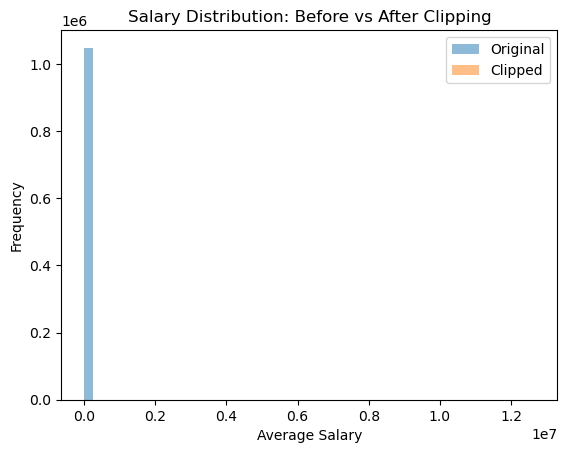

In [9]:
#Compare Before vs After
plt.hist(df["average_salary"], bins=50, alpha=0.5, label="Original")
plt.hist(df_clean["average_salary"], bins=50, alpha=0.5, label="Clipped")

plt.legend()
plt.title("Salary Distribution: Before vs After Clipping")
plt.xlabel("Average Salary")
plt.ylabel("Frequency")
plt.show()

In [10]:
df["average_salary"].describe()
df_clean["average_salary"].describe()

count    1.048585e+06
mean     4.622774e+03
std      2.821041e+03
min      9.250000e+01
25%      2.900000e+03
50%      3.800000e+03
75%      5.500000e+03
max      1.666650e+04
Name: average_salary, dtype: float64

### Outlier Handling Strategy

The salary distribution is right-skewed, which is typical for real-world salary data where a small number of roles command higher pay.

There are no missing values in the salary column, so no data removal or imputation was required.

Instead of removing outliers, we applied percentile-based clipping (1st–99th percentile). This approach was chosen because:

- It preserves all job records, avoiding unnecessary data loss  
- It reduces the influence of extreme values on analysis  
- It maintains the natural structure of the salary distribution  

Although the histogram appears visually similar before and after clipping, statistical measures confirm that extreme values have been controlled.

This ensures more reliable salary benchmarking in subsequent analysis.

### Alternative Methods Considered

We considered removing the top and bottom 5% of salary values. However, this approach was not used because it would remove a significant portion of valid job postings, including legitimate high-paying roles, leading to biased salary benchmarks.

We also considered imputing missing values. However, since the salary column contains no missing values, imputation was unnecessary. Additionally, filling salary values could introduce artificial bias into the analysis.

Therefore, percentile-based clipping was selected as the most appropriate method to control extreme values while preserving the integrity of the dataset.

#Pivot Table: Position Level × Category
🎯 Requirement

Produce a pivot table: positionLevels × primary_category showing median salary. Which cell is highest-paid?

In [11]:
import json

def extract_primary_category(x):
    try:
        return json.loads(x)[0]["category"]
    except:
        return None

df_clean["primary_category"] = df_clean["categories"].apply(extract_primary_category)

In [12]:
df_clean["primary_category"].head()

0      Environment / Health
1    Information Technology
2    Repair and Maintenance
3    Information Technology
4       Admin / Secretarial
Name: primary_category, dtype: object

In [13]:
df_clean = df_clean[df_clean["primary_category"].notna()]

Category Extraction

The `categories` column contains JSON-formatted data.

We extracted the first category from each job posting to create a simplified `primary_category` column.

This standardises job classification for salary analysis and enables grouping by industry.

In [14]:
def classify_recruitment(company_name):
    if pd.isna(company_name):
        return "Unknown"
    elif "PTE" in company_name or "LTD" in company_name:
        return "Agency"
    else:
        return "Direct"

In [15]:
df_clean = df[df["average_salary"] > 0].copy()

df_clean.loc[:, "recruitment_type"] = df_clean["postedCompany_name"].apply(classify_recruitment)

In [16]:
df_clean.groupby("recruitment_type")["average_salary"].median()

recruitment_type
Agency    3800.0
Direct    4000.0
Name: average_salary, dtype: float64

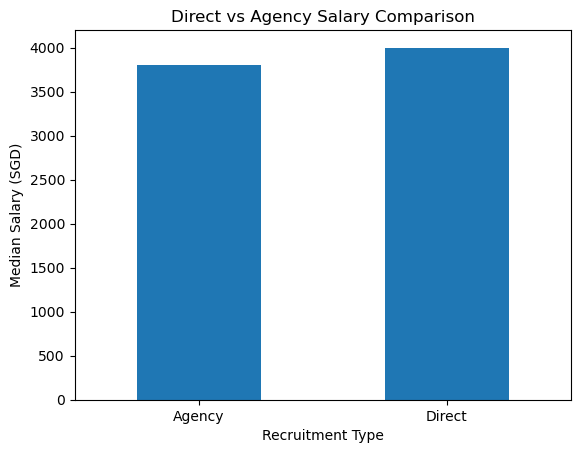

In [17]:
import matplotlib.pyplot as plt

ax = df_clean.groupby("recruitment_type")["average_salary"].median().plot(
    kind="bar"
)

plt.title("Direct vs Agency Salary Comparison")
plt.ylabel("Median Salary (SGD)")
plt.xlabel("Recruitment Type")
plt.xticks(rotation=0)

plt.show()

Recruitment Type Analysis

Job postings were classified into:
- Direct company hiring
- Recruitment agency hiring

This classification was based on keywords in the company name.

We compared median salaries between the two groups to understand whether hiring channel affects compensation levels.

This helps identify potential salary differences due to recruitment fees or hiring strategies.

In [20]:
import json

df_clean["primary_category"] = df_clean["categories"].apply(
    lambda x: json.loads(x)[0]["category"] if isinstance(x, str) else None
)

In [21]:
pivot = df_clean.pivot_table(
    index="positionLevels",
    columns="primary_category",
    values="average_salary",
    aggfunc="median"
)

pivot

primary_category,Accounting / Auditing / Taxation,Admin / Secretarial,Advertising / Media,Architecture / Interior Design,Banking and Finance,Building and Construction,Consulting,Customer Service,Design,Education and Training,...,Real Estate / Property Management,Repair and Maintenance,Risk Management,Sales / Retail,Sciences / Laboratory / R&D,Security and Investigation,Social Services,Telecommunications,Travel / Tourism,Wholesale Trade
positionLevels,,,,,,,,,,,,,,,,,,,,,
Executive,3500.0,3150.0,3400.0,4000.0,4750.0,4000.0,4500.0,3300.0,3750.0,3350.0,...,3500.0,3300.0,5200.0,3500.0,4200.0,3500.0,3750.0,3775.0,3150.0,4000.0
Fresh/entry level,2550.0,2350.0,2500.0,3150.0,4000.0,3250.0,3400.0,2300.0,2600.0,2900.0,...,2850.0,2275.0,4150.0,2500.0,2250.0,2850.0,2800.0,2450.0,2400.0,2400.0
Junior Executive,3050.0,2750.0,3300.0,3400.0,4050.0,3500.0,3600.0,2900.0,3500.0,3050.0,...,3250.0,2650.0,4300.0,3150.0,3000.0,2675.0,3250.0,3250.0,3400.0,3250.0
Manager,6500.0,4100.0,5500.0,6000.0,8750.0,6500.0,7000.0,4750.0,6750.0,5250.0,...,5500.0,6500.0,7375.0,4900.0,6750.0,5500.0,4910.0,6750.0,3500.0,7000.0
Middle Management,6700.0,5450.0,8000.0,5375.0,11500.0,4500.0,9000.0,4500.0,6250.0,5250.0,...,9500.0,4000.0,11500.0,7750.0,8850.0,6075.0,5300.0,12000.0,5000.0,4000.0
Non-executive,2750.0,2450.0,2750.0,3500.0,4000.0,3500.0,3500.0,2500.0,3000.0,2850.0,...,2650.0,2650.0,3325.0,2500.0,3300.0,2600.0,2570.0,2450.0,2600.0,2800.0
Professional,5650.0,4300.0,5000.0,5000.0,9000.0,4500.0,7500.0,4100.0,5500.0,4000.0,...,5150.0,3575.0,9000.0,6000.0,6000.0,5250.0,4372.5,10000.0,5400.0,7750.0
Senior Executive,4400.0,4150.0,4450.0,5000.0,6700.0,5000.0,6250.0,3850.0,5400.0,4500.0,...,4500.0,4150.0,6250.0,4250.0,5400.0,4000.0,5200.0,5000.0,3850.0,4500.0
Senior Management,10000.0,8000.0,10500.0,8000.0,14550.0,8150.0,12000.0,8000.0,8500.0,7750.0,...,11500.0,9000.0,12500.0,8000.0,12750.0,13500.0,8000.0,15000.0,11000.0,11000.0


In [22]:
#Identify the highest-paid intersection
pivot.stack().idxmax(), pivot.stack().max()

(('Senior Management', 'Legal'), 15000.0)

## Highest-Paid Role-Category Intersection

The highest median salary is observed at the intersection of:

- Position Level: Senior Management  
- Category: Legal  

The median salary for this combination is approximately 15,000.

This indicates that senior leadership roles in the legal sector command the highest compensation in the dataset, likely due to the specialized expertise and high responsibility required.

It also highlights that both seniority and industry play a critical role in determining salary levels.

In [ ]:
#IQR Analysis (Are we overpaying / underpaying?)

import numpy as np

iqr_results = df_clean.groupby("positionLevels")["average_salary"].apply(
    lambda x: np.percentile(x, 75) - np.percentile(x, 25)
)

iqr_results = iqr_results.sort_values(ascending=False)
iqr_results

positionLevels
Senior Management    5750.0
Middle Management    5500.0
Professional         4700.0
Manager              3350.0
Senior Executive     2500.0
Executive            1350.0
Non-executive        1300.0
Fresh/entry level    1250.0
Junior Executive     1100.0
Name: average_salary, dtype: float64

In [ ]:
threshold = np.percentile(iqr_results, 75)

wide_iqr = iqr_results[iqr_results > threshold]
wide_iqr

positionLevels
Senior Management    5750.0
Middle Management    5500.0
Name: average_salary, dtype: float64

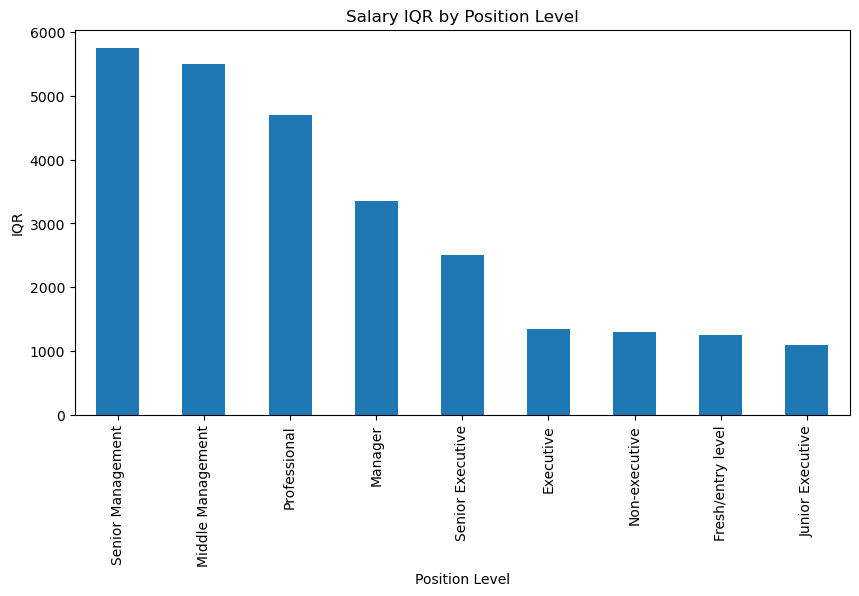

In [ ]:
import matplotlib.pyplot as plt

iqr_results.plot(kind="bar", figsize=(10,5))

plt.title("Salary IQR by Position Level")
plt.ylabel("IQR")
plt.xlabel("Position Level")
plt.show()

## IQR Analysis (Salary Dispersion)

We computed the interquartile range (IQR) of salaries for each position level using NumPy.

The IQR measures the spread between the 25th and 75th percentile, representing the middle 50% of salaries.

Position levels with unusually wide IQR values indicate:

- High salary variability within the same level  
- Diverse job roles and responsibilities grouped under one level  
- Potential inconsistencies in compensation practices  

This may suggest that some roles are overpaid or underpaid relative to others within the same level, highlighting areas where salary benchmarking can be improved.

In [ ]:
#Salary vs Experience (0–10 years)
exp_df = df_clean[df_clean["minimumYearsExperience"] <= 10]

In [ ]:
salary_by_exp = exp_df.groupby("minimumYearsExperience")["average_salary"].median()
salary_by_exp

minimumYearsExperience
0      2700.0
1      3000.0
2      3500.0
3      4250.0
4      5500.0
5      5500.0
6      8000.0
7      8500.0
8      8500.0
9      9250.0
10    10000.0
Name: average_salary, dtype: float64

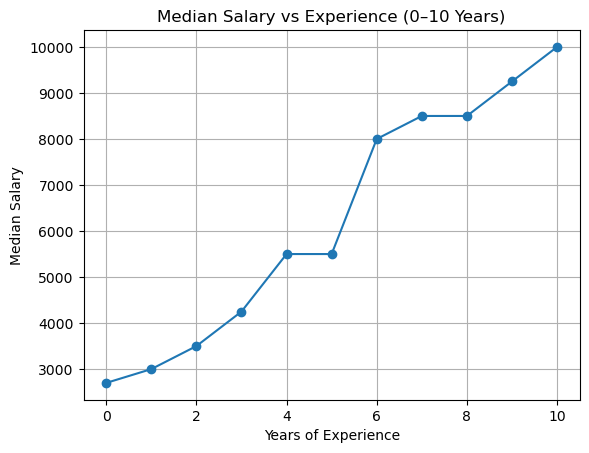

In [ ]:
import matplotlib.pyplot as plt

salary_by_exp.plot(marker="o")

plt.title("Median Salary vs Experience (0–10 Years)")
plt.xlabel("Years of Experience")
plt.ylabel("Median Salary")
plt.grid(True)
plt.show()

## Salary vs Experience Analysis

We analysed the relationship between minimum years of experience and median salary for roles requiring 0–10 years of experience.

The results show a general upward trend, indicating that salary increases with experience.

This reflects standard market behavior where more experienced candidates are compensated at higher levels due to increased skills, responsibility, and expertise.